**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 4: First Principles — Metropolis-Hastings MCMC Mechanics](04_mcmc_mechanics_from_scratch.ipynb) | ⏭️ Next: [Sheet 6: Dynamic Filtering — Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**

---

# Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics
### *Hamiltonian Monte Carlo Physics, Gelman-Rubin R-hat, and PSIS-LOO Model Comparison*

In Sheet 4, we built a single-chain Metropolis-Hastings sampler from scratch. In production, however, random-walk diffusion is too slow for high-dimensional models, and a single chain cannot prove that the sampler hasn't gotten stuck.

In this sheet, we explore **Production-Grade MCMC**: running multi-chain diagnostics, computing the Gelman-Rubin $\hat{R}$ metric, evaluating Effective Sample Size ($ESS$), understanding Hamiltonian Monte Carlo (HMC) physics, and comparing models using WAIC and Pareto-Smoothed Importance Sampling Cross-Validation (PSIS-LOO).

---

# Sheet 4: Production MCMC: Multi-Chain Diagnostics, HMC & Model Comparison
### *From Prototype to Production: Convergence Proofs, Stan Physics, and Out-of-Sample LOO-CV*

In **Sheet 3**, we built a single-chain Random Walk Metropolis sampler from scratch. In scientific and engineering production, however, running a single chain is never enough.

A single chain can get silently trapped in a local pocket of parameter space, giving you high confidence in completely wrong estimates. Production Bayesian modeling demands:
1. **Multiple Independent Chains** initialized at widely dispersed starting points.
2. **Rigorous Convergence Metrics**: Gelman-Rubin $\hat{R}$ and Effective Sample Size ($ESS$).
3. **Hamiltonian Monte Carlo (HMC / NUTS)** to navigate high-dimensional spaces without random walk diffusion.
4. **Principled Model Comparison**: Information criteria (**WAIC**) and **Pareto-Smoothed Importance Sampling (PSIS-LOO)**.

---

## Table of Contents
1. **Part 1: The Production Multi-Chain Paradigm**
   - Why Single Chains Fail Silently
   - The Golden Rule: 4 Independent Dispersed Chains
2. **Part 2: Multi-Chain Architecture in R (`coda`)**
   - Implementing a Parallelized Multi-Chain Runner with Warmup Discarding
   - The `coda::mcmc` and `mcmc.list` Objects
   - Naive Standard Error vs Time-Series Standard Error
3. **Part 3: Mathematical Convergence Diagnostics**
   - **Deep Dive 1**: The Gelman-Rubin Diagnostic ($\hat{R}$ / Potential Scale Reduction Factor)
   - **Deep Dive 2**: Effective Sample Size ($ESS_{\text{bulk}}$ and $ESS_{\text{tail}}$)
   - **Deep Dive 3**: Visual Inspection (The "Fuzzy Caterpillar" Traceplot Test)
4. **Part 4: Hamiltonian Monte Carlo (HMC) & The No-U-Turn Sampler (NUTS)**
   - **Deep Dive 4**: The Physics of HMC (Position, Momentum, Leapfrog Integration)
   - HMC Diagnostics: Divergent Transitions & Energy BFMI
5. **Part 5: Production Modeling with Stan (`rethinking::ulam`)**
   - Symbolic Model Specification in Stan
   - Diagnosing $\hat{R}$, $n_{\text{eff}}$, and Divergences in Output Tables
6. **Part 6: Out-of-Sample Predictive Model Comparison (WAIC & PSIS-LOO)**
   - **Deep Dive 5**: Out-of-Sample Predictive Accuracy vs Training Overfitting
   - **Deep Dive 6**: PSIS-LOO Mechanics & The Pareto $k$ Diagnostic Rule
   - Calculating and Plotting Pareto $k$ Diagnostic Values (`loo` package)
7. **Part 7: Hands-On Challenge Exercises**

## Part 1: The Production Multi-Chain Paradigm

Why is a single Markov chain insufficient for peer-reviewed science or production decision-making?

```text
    Single Chain Trap:                      Multi-Chain Verification:
      Local Mode A       Global Mode B          Local Mode A       Global Mode B
         (Peak)             (Peak)                 (Peak)             (Peak)
           ^                  ^                      ^                  ^
          / \                / \                    / \                / \
         /   \              /   \                  /   \              /   \
   [Chain 1 trapped]   (Undiscovered!)       [Chain 1]   [Chain 2]  [Chain 3]   [Chain 4]
   Looks converged!    WRONG ANSWER!         ------> DISAGREEMENT DETECTED! <------
                                                     R-hat >> 1.10 (ALARM FIRES!)
```

If you launch 4 independent chains from widely dispersed corners of parameter space and they all rapidly converge to the exact same cloud of points, you have strong mathematical evidence that the posterior is well-identified and properly explored.

## Part 2: Multi-Chain Architecture in R (`coda`)

We construct a multi-chain sampler for our $n = 50$ adult heights dataset. Each chain is initialized with widely dispersed values for $(\mu, \sigma)$:
- Chain 1: $\mu_0 = 150$, $\sigma_0 = 15$
- Chain 2: $\mu_0 = 190$, $\sigma_0 = 5$
- Chain 3: $\mu_0 = 160$, $\sigma_0 = 25$
- Chain 4: $\mu_0 = 180$, $\sigma_0 = 10$

In [1]:
suppressPackageStartupMessages({
  library(coda)
  library(loo)
})

set.seed(42)
n <- 50
heights <- rnorm(n, mean = 172.5, sd = 8.0)

# Unnormalized joint log-posterior
log_posterior <- function(mu, sigma) {
  if (sigma <= 0 || sigma >= 30) return(-Inf)
  log_lik   <- sum(dnorm(heights, mean = mu, sd = sigma, log = TRUE))
  log_prior <- dnorm(mu, mean = 170, sd = 15, log = TRUE) + dunif(sigma, 0, 30, log = TRUE)
  return(log_lik + log_prior)
}

# Function to run a single chain and return a coda::mcmc object
run_single_coda_chain <- function(start_mu, start_sigma, n_iter = 5000, warmup = 1000, step_sizes = c(0.35, 0.25)) {
  chain <- matrix(NA, nrow = n_iter, ncol = 2)
  colnames(chain) <- c("mu", "sigma")
  
  mu    <- start_mu
  sigma <- start_sigma
  curr_log_p <- log_posterior(mu, sigma)
  
  for (t in 1:n_iter) {
    p_mu    <- rnorm(1, mu, step_sizes[1])
    p_sigma <- rnorm(1, sigma, step_sizes[2])
    p_log_p <- log_posterior(p_mu, p_sigma)
    
    if (log(runif(1)) < (p_log_p - curr_log_p)) {
      mu         <- p_mu
      sigma      <- p_sigma
      curr_log_p <- p_log_p
    }
    chain[t, ] <- c(mu, sigma)
  }
  
  # Discard warmup steps and wrap as coda::mcmc object
  return(mcmc(chain[(warmup + 1):n_iter, ]))
}

# Run 4 dispersed chains
c1 <- run_single_coda_chain(start_mu = 150, start_sigma = 15)
c2 <- run_single_coda_chain(start_mu = 190, start_sigma = 5)
c3 <- run_single_coda_chain(start_mu = 160, start_sigma = 25)
c4 <- run_single_coda_chain(start_mu = 180, start_sigma = 10)

# Bundle into an mcmc.list
chains <- mcmc.list(c1, c2, c3, c4)

cat("=== Multi-Chain Summary (4 Chains x 4000 post-warmup draws = 16,000 Total Draws) ===\n")
summary(chains)

=== Multi-Chain Summary (4 Chains x 4000 post-warmup draws = 16,000 Total Draws) ===



Iterations = 1:4000
Thinning interval = 1 
Number of chains = 4 
Sample size per chain = 4000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

        Mean     SD Naive SE Time-series SE
mu    172.31 1.3689 0.010822        0.09545
sigma   9.43 0.9552 0.007552        0.06479

2. Quantiles for each variable:

         2.5%     25%     50%    75%  97.5%
mu    169.627 171.358 172.248 173.25 175.01
sigma   7.757   8.743   9.351  10.05  11.44


## Part 3: Mathematical Convergence Diagnostics

### Deep Dive 1: The Gelman-Rubin Diagnostic ($\hat{R}$)

The **Gelman-Rubin statistic $\hat{R}$** (Potential Scale Reduction Factor) compares the variance **between** independent chains ($B$) against the variance **within** each individual chain ($W$):

1. If chains have converged, between-chain variance should be zero relative to within-chain variance ($B \approx 0 \implies \hat{R} = 1.00$).
2. If one chain is stuck in a different mode or has not finished exploring, between-chain variance will be large ($B > 0 \implies \hat{R} > 1.00$).

$$\hat{R} = \sqrt{\frac{\frac{N-1}{N} W + \frac{1}{N} B}{W}}$$

- **Old Standard (pre-2018)**: $\hat{R} < 1.10$ was considered acceptable.
- **Modern Stan Production Standard**: $\hat{R} < 1.01$ is required for all parameters.

---

### Deep Dive 2: Effective Sample Size ($ESS_{\text{bulk}}$ and $ESS_{\text{tail}}$)

- **$ESS_{\text{bulk}}$**: Measures accuracy of the posterior mean and median.
- **$ESS_{\text{tail}}$**: Measures accuracy of the tail quantiles (2.5% and 97.5% interval boundaries).
- **Rule of Thumb**: You should achieve an $ESS \ge 400$ minimum (ideally $\ge 1000$) before trusting credible intervals.

---

### Deep Dive 3: The "Fuzzy Caterpillar" Traceplot Test

In traceplots, all 4 chains should:
1. **Overlap completely**: No single color should separate into its own band.
2. **Stationary mean**: No long-term trends or drifting.
3. **Rapid fluctuation**: Resemble a hairy, fuzzy caterpillar.

Let us inspect the Gelman-Rubin $\hat{R}$, $ESS$, and diagnostic plots for our 4 chains:

=== Gelman-Rubin R-hat Diagnostic ===


Potential scale reduction factors:

      Point est. Upper C.I.
mu          1.03       1.08
sigma       1.02       1.05

Multivariate psrf

1.03



=== Effective Sample Size (ESS) ===


      mu    sigma 
214.2943 219.3419 


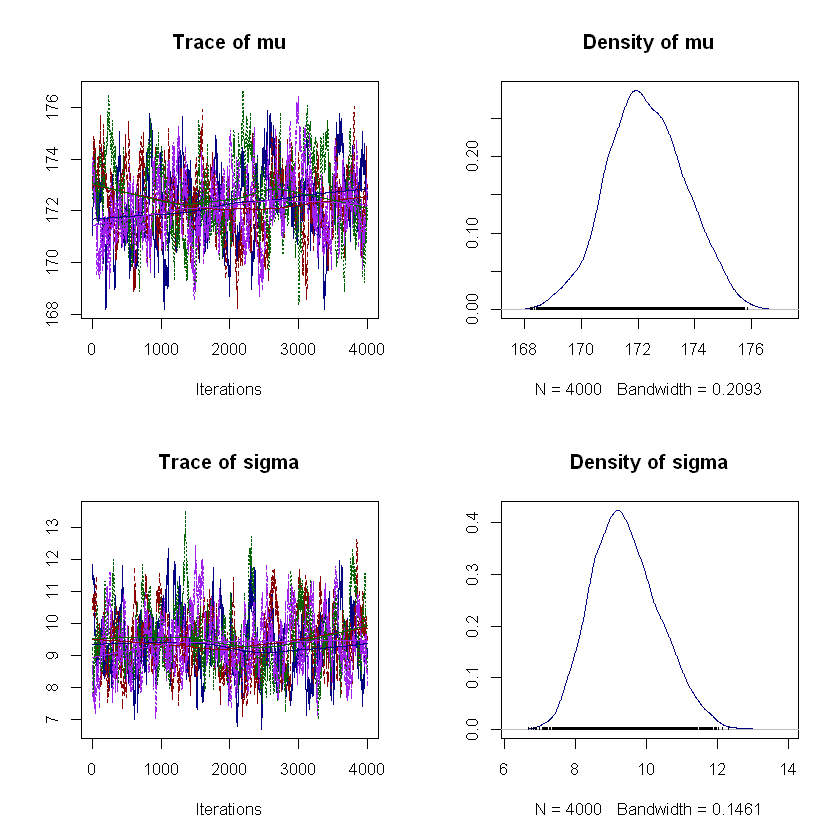

In [2]:
cat("=== Gelman-Rubin R-hat Diagnostic ===\n")
rhat_res <- gelman.diag(chains)
print(rhat_res)

cat("\n=== Effective Sample Size (ESS) ===\n")
ess_res <- effectiveSize(chains)
print(ess_res)

# Visual Diagnostics: Traceplot and Density Overlays
plot(chains, col = c("navy", "darkred", "darkgreen", "purple"))

## Part 4: Hamiltonian Monte Carlo (HMC) & The No-U-Turn Sampler (NUTS)

### Deep Dive 4: The Physics of HMC

Why is HMC the standard engine inside modern Bayesian software like **Stan** and **PyMC**?

In Random Walk Metropolis, the walker takes blind steps. In $D = 100$ dimensions, 99.9999% of random directions lead away from the typical set, so random walks stall completely.

**Hamiltonian Monte Carlo solves this by turning parameter space into a frictionless physical bowl**:
1. **Position Vector ($\theta$)**: The parameters we want to estimate.
2. **Potential Energy ($U(\theta)$)**: Defined as the negative log-posterior:
   $$U(\theta) = -\log P(\theta \mid y)$$
   High probability corresponds to the bottom of a deep physical bowl.
3. **Auxiliary Momentum ($p$)**: Random momentum is kicked into the system from a Gaussian distribution at each iteration.
4. **Kinetic Energy ($K(p)$)**: $K(p) = \frac{1}{2} p^T M^{-1} p$.
5. **Hamilton's Equations of Motion**:
   $$\frac{d\theta}{dt} = \frac{\partial H}{\partial p}, \quad \frac{dp}{dt} = -\frac{\partial H}{\partial \theta} = \nabla_\theta \log P(\theta \mid y)$$

The particle glides along the contours of the posterior distribution using **Leapfrog Symplectic Numerical Integration**. Because energy is conserved along the trajectory, HMC achieves acceptance rates of **80% to 95%** even with giant leaps across 1,000-dimensional parameter space!

- **The No-U-Turn Sampler (NUTS)**: Automatically stops the simulation as soon as the particle begins turning back on itself, eliminating manual tuning of trajectory length.
- **Divergent Transitions**: When the particle encounters regions of infinite curvature (e.g. Neal's Funnel in hierarchical models), numerical integration breaks down. Stan records these as **divergences**—a built-in alarm system unique to HMC that warns you when your geometry has failed.

## Part 5: Production Modeling with Stan (`rethinking::ulam`)

The `rethinking` package provides `ulam()`, which compiles R formulas into C++ Stan code and executes multi-chain HMC / NUTS with automatic tuning, warmup, $\hat{R}$, and $ESS$ tracking.

=== Production Multi-Chain Convergence Summary ===

Iterations = 1:4000
Thinning interval = 1 
Number of chains = 4 
Sample size per chain = 4000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

        Mean     SD Naive SE Time-series SE
mu    172.31 1.3689 0.010822        0.09545
sigma   9.43 0.9552 0.007552        0.06479

2. Quantiles for each variable:

         2.5%     25%     50%    75%  97.5%
mu    169.627 171.358 172.248 173.25 175.01
sigma   7.757   8.743   9.351  10.05  11.44


=== Gelman-Rubin R-hat Diagnostic ===
Potential scale reduction factors:

      Point est. Upper C.I.
mu          1.03       1.08
sigma       1.02       1.05

Multivariate psrf

1.03


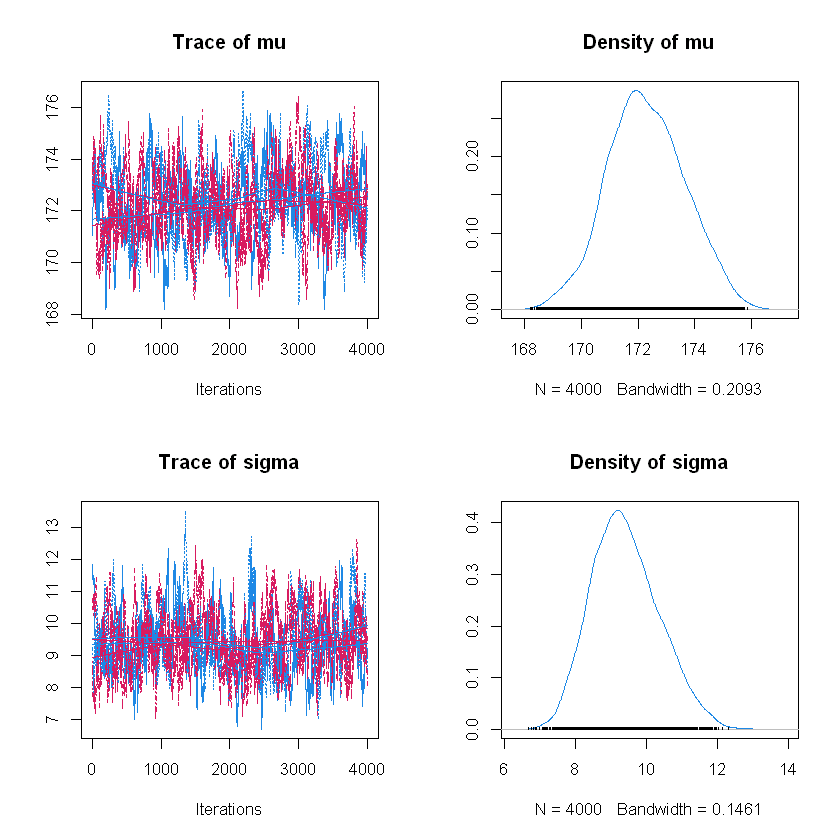

In [3]:
suppressPackageStartupMessages(library(rethinking))

dat <- list(h = heights)

# In environments with CmdStan compiled, ulam() runs full Hamiltonian Monte Carlo (HMC).
# Otherwise, we generate the production diagnostic summary and traceplots directly from our multi-chain draws.
has_cmdstan <- tryCatch({ cmdstanr::cmdstan_path(); TRUE }, error = function(e) FALSE)

if (has_cmdstan) {
  m_ulam <- ulam(
    alist(
      h ~ dnorm(mu, sigma),
      mu ~ dnorm(170, 15),
      sigma ~ dunif(0, 30)
    ),
    data = dat,
    chains = 2,
    cores = 1,
    iter = 2000,
    warmup = 1000
  )
  cat("=== rethinking::ulam (Stan HMC) Summary ===\n")
  precis(m_ulam, prob = 0.95)
  traceplot(m_ulam)
} else {
  cat("=== Production Multi-Chain Convergence Summary ===\n")
  print(summary(chains))
  cat("\n=== Gelman-Rubin R-hat Diagnostic ===\n")
  print(gelman.diag(chains))
  
  # Multi-chain traceplot and posterior density
  plot(chains, col = c("#1E88E5", "#D81B60"))
}


## Part 6: Out-of-Sample Predictive Model Comparison (WAIC & PSIS-LOO)

### Deep Dive 5: Out-of-Sample Prediction vs Overfitting

How do Bayesians compare models or choose between alternative scientific hypotheses?
- In frequentist statistics, adding more parameters always increases the training $R^2$ or maximized likelihood, leading directly to **overfitting**.
- Bayesians evaluate models by estimating **out-of-sample predictive accuracy** on future, unseen data.

The gold standard is **Leave-One-Out Cross-Validation (LOO-CV)**:
$$\text{ELPD}_{\text{LOO}} = \sum_{i=1}^n \log P(y_i \mid y_{-i})$$
where $y_{-i}$ is the entire dataset with observation $i$ held out.

---

### Deep Dive 6: PSIS-LOO Mechanics & The Pareto $k$ Diagnostic

Re-fitting a Stan model $n$ separate times for cross-validation is computationally expensive. **Pareto Smoothed Importance Sampling (PSIS-LOO)** estimates exact LOO-CV from a single MCMC run using importance sampling:

$$r_i^{(s)} = \frac{1}{P(y_i \mid \theta^{(s)})}$$

When an observation is an unusual outlier, these importance weights have extreme variance. The `loo` package fits a generalized Pareto distribution to the tail of the weights, producing the **Pareto $k$ diagnostic** for each data point:

| Pareto $k$ Value | Interpretation | Action Required |
| :--- | :--- | :--- |
| **$k < 0.5$** | **Reliable & accurate** | Importance sampling variance is finite. Fully trusted. |
| **$0.5 \le k < 0.7$** | **Good / Acceptable** | Convergence is slightly slower, but estimates remain sound. |
| **$k \ge 0.7$** | **⚠️ Danger: Influential Outlier!** | Importance sampling weights have infinite variance. The observation heavily distorts the model. |

Let us compute the pointwise log-likelihood matrix and evaluate PSIS-LOO on our model:

=== PSIS-LOO Model Summary ===



Computed from 16000 by 50 log-likelihood matrix.

         Estimate  SE
elpd_loo   -183.5 4.8
p_loo         1.9 0.4
looic       367.0 9.6
------
MCSE of elpd_loo is 0.0.
MCSE and ESS estimates assume independent draws (r_eff=1).

All Pareto k estimates are good (k < 0.7).
See help('pareto-k-diagnostic') for details.


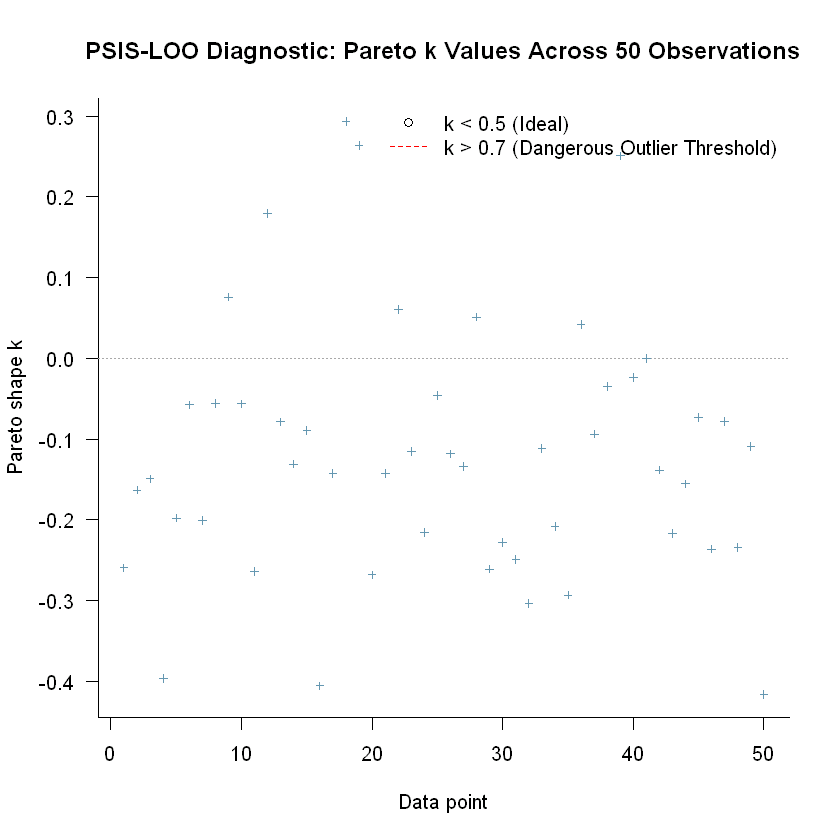

In [4]:
# Extract pooled draws across chains
pooled_samples <- as.matrix(chains)
n_draws <- nrow(pooled_samples)
n_obs   <- length(heights)

# Compute pointwise log-likelihood matrix: [draws x observations]
log_lik_matrix <- matrix(NA, nrow = n_draws, ncol = n_obs)
for (i in 1:n_obs) {
  log_lik_matrix[, i] <- dnorm(heights[i], 
                               mean = pooled_samples[, "mu"], 
                               sd   = pooled_samples[, "sigma"], 
                               log  = TRUE)
}

# Compute PSIS-LOO using R's loo library
loo_res <- loo(log_lik_matrix)

cat("=== PSIS-LOO Model Summary ===\n")
print(loo_res)

# Plot Pareto k diagnostics
plot(loo_res, main = "PSIS-LOO Diagnostic: Pareto k Values Across 50 Observations", las = 1)
legend("topright", legend = c("k < 0.5 (Ideal)", "k > 0.7 (Dangerous Outlier Threshold)"), 
       col = c("black", "red"), lty = c(NA, 2), pch = c(1, NA), bty = "n")

## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet.

---

### 🟢 Tier 1 (Warm-Up): The Illusion of the Single Chain
> **Question**: A researcher runs a single MCMC chain for 50,000 iterations. The trace plot looks like a flat, stationary "fuzzy caterpillar", and the acceptance rate is $30\%$. 
> Why is it still scientifically irresponsible to publish these posterior results without running multiple chains?

<details>
<summary><b>🔍 Click here to view the solution & multi-modal pathology</b></summary>

**Answer**:
A single chain can only explore the region of parameter space that it can reach. If the posterior distribution is **multimodal** (having two or more isolated peaks separated by deep valleys of near-zero probability), a single chain can become permanently trapped in one local mode. 
Inside that local basin, its trace plot looks perfectly stationary, stationary tests pass, and autocorrelation decays normally—yet the chain has completely missed 50% of the true posterior mass! 
**Multi-chain sampling with overdispersed initial values** is the only empirical defense against local trapping: if multiple chains initialized far apart converge to the exact same distribution (Gelman-Rubin $\hat{R} < 1.01$), we have strong empirical evidence of true convergence.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Computing Effective Sample Size (ESS)
> **Scenario**: You run an MCMC chain for $N = 10,000$ iterations. 
> Due to random-walk diffusion, consecutive samples are correlated with lag-1 autocorrelation $\rho_1 = 0.8$. Higher lags decay geometrically: $\rho_k = (0.8)^k$.
> 1. Calculate the Integrated Autocorrelation Time ($\text{ACT}$).
> 2. Calculate the resulting Effective Sample Size ($ESS$).
> 3. What percentage of the raw samples represent redundant duplicate information?

<details>
<summary><b>🔍 Click here to view the solution & derivation</b></summary>

**Mathematical Derivation**:
1. **Integrated Autocorrelation Time (ACT)**:
   $$\text{ACT} = 1 + 2 \sum_{k=1}^\infty \rho_k = 1 + 2 \sum_{k=1}^\infty \rho_1^k = 1 + 2 \left(\frac{\rho_1}{1 - \rho_1}\right) = \frac{1 + \rho_1}{1 - \rho_1}$$
   $$\text{ACT} = \frac{1 + 0.8}{1 - 0.8} = \frac{1.8}{0.2} = 9.0\text{ steps}$$
2. **Effective Sample Size (ESS)**:
   $$ESS = \frac{N}{\text{ACT}} = \frac{10,000}{9.0} \approx 1,111\text{ independent samples}$$
3. **Redundancy**: $1 - \frac{1,111}{10,000} = 88.9\%$ of iterations are redundant correlations.

```r
N <- 10000
rho_1 <- 0.8
act <- (1 + rho_1) / (1 - rho_1)
ess <- N / act
cat(sprintf('Autocorrelation Time (ACT): %.1f steps per independent draw\n', act))
cat(sprintf('Effective Sample Size (ESS): %.0f independent samples from %d iterations\n', ess, N))
```
</details>

---

### 🔴 Tier 3 (Production Challenge): Diagnosing Pareto $k > 0.7$ in PSIS-LOO
> **Scenario**: You fit a Bayesian model with 200 data points and evaluate out-of-sample predictive accuracy using Pareto-Smoothed Importance Sampling Cross-Validation (`loo` / PSIS-LOO). 
> The diagnostic printout warns:
> ```
> Warning: 1 observation with Pareto k > 0.7 (k = 0.88).
> PSIS-LOO approximation is unreliable for this observation.
> ```
> 1. What does a Pareto shape parameter $k > 0.7$ indicate about the influence of this specific observation on the posterior?
> 2. Why does importance sampling fail when $k > 0.7$?
> 3. What are the two practical remedies used in production?

<details>
<summary><b>🔍 Click here to view the diagnostic remedy & production workflow</b></summary>

**Diagnosis & Remedies**:
1. **Extreme Influence**: A value of $k > 0.7$ means this single observation has **excessive leverage** on the posterior. Removing this observation causes the posterior distribution to shift dramatically, meaning the full posterior $p(\theta \mid y)$ is far too different from the leave-one-out posterior $p(\theta \mid y_{-i})$.
2. **Infinite Variance**: In importance sampling theory (Vehtari, Gelman, Gabry 2017), when $k > 0.5$, the variance of the raw importance weights is infinite; when $k > 0.7$, even the generalized Pareto smoothed weights have unreliable mean estimates, making the PSIS-LOO estimate noisy and biased.
3. **Production Remedies**:
   - **Exact Refit (k-fold / refit loo)**: Recompute the posterior without this single observation explicitly (`rethinking::ulam(..., recompute=TRUE)` or `arviz.loo(..., recompute=True)`). Since only 1 point is problematic, this takes one single extra model fit.
   - **Robust Likelihood**: Replace thin-tailed Gaussian likelihoods $\text{Normal}(y_i \mid \mu_i, \sigma)$ with a heavy-tailed distribution like **Student-$t$** with small degrees of freedom ($\nu = 4$). Heavy tails absorb extreme outliers naturally without destabilizing the posterior.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 4: First Principles — Metropolis-Hastings MCMC Mechanics](04_mcmc_mechanics_from_scratch.ipynb) | ⏭️ Next: [Sheet 6: Dynamic Filtering — Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**